# Sequence Search with Malva

This notebook demonstrates how to query arbitrary nucleotide sequences against
a Malva index and visualize the results at single-cell resolution.

We will:

1. Load the clustered PBMC data from the previous step
2. Query a CD3E transcript isoform sequence against the index
3. Project query results onto the UMAP and compare with gene-level quantification

**Prerequisites:** Run `1_run_malva.sh` and `2_simple_analysis.ipynb` first.

## Load clustered data

In [31]:
import scanpy as sc
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import dnaio

from malva.indexes import MalvaIndex

In [ ]:
# Load the clustered h5ad from the previous notebook
adata = sc.read_h5ad("quant/pbmc_1k_v3/pseudoquant_clustered.h5ad")

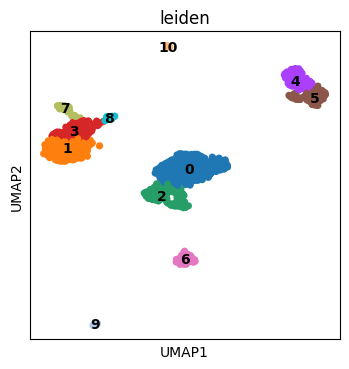

In [ ]:
# Quick look at the clusters
plt.rcParams["figure.figsize"] = (4, 4)
sc.pl.umap(adata, color=["leiden"], wspace=0.4, ncols=3, legend_loc = "on data")

## Load the Malva index

In [ ]:
# Open the index we built in step 1
mindex = MalvaIndex("indices/pbmc_1k_v3")

## Query a custom sequence

We query `sequence.fa`, which contains one isoform of the CD3E gene.

This demonstrates how you can search for any sequence of interest:
transcript isoforms, viral sequences, circular RNAs, etc.

In [ ]:
# Load the query sequence from FASTA file
query = []
with dnaio.open("sequence.fa") as fasta:
    for record in fasta:
        query.append([record.sequence])

In [ ]:
# Search the index for cells containing k-mers from the query sequence
mindex.open()
results = mindex.where(
    sequence = query,
    sliding_size = 64,        # window size for k-mer matching
    pct_threshold = 0.65,     # minimum fraction of k-mers that must match
    count_at_most = 100000,   # upper count threshold
    count_at_least = 0,       # lower count threshold
)
mindex.close()

## Project results onto cells

In [ ]:
# Convert results to a dataframe and merge with cell annotations
df_results = pd.DataFrame({
    "cell": results[0][0],
    "expression": results[0][1]
})
df_results.index = df_results["cell"].astype(str)

In [ ]:
# Add query expression to the AnnData object
adata.obs["query_expression"] = np.nan_to_num(
    adata.obs.merge(df_results, left_index=True, right_index=True, how="left")["expression"].values,
    nan=0
)

## Compare sequence query with gene-level quantification

The query sequence is a CD3E isoform. We can compare our sequence-level
search results with the gene-level CD3E expression from `malva quant`.

The sequence query results correlate with CD3E expression,
as both capture T cell populations. Sequence-level queries
can detect isoform-specific expression patterns not visible at the gene level.

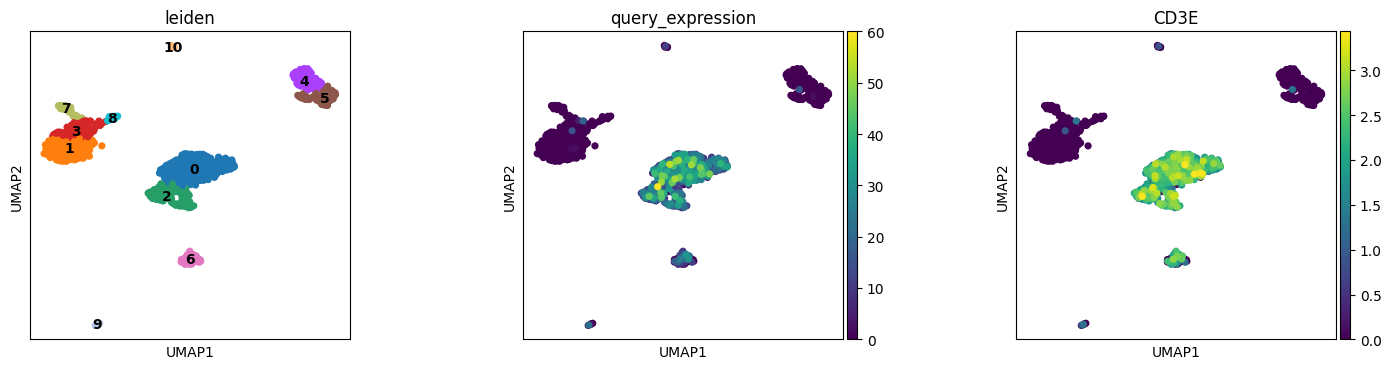

In [35]:
plt.rcParams["figure.figsize"] = (4, 4)
sc.pl.umap(adata, color=["leiden", "query_expression", "CD3E"], wspace=0.4, ncols=3, legend_loc = "on data")